In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [12]:
import pandas as pd

n = int(input("Enter number of students: "))

data = {
    "math_score": [],
    "programming_skill": [],
    "communication_skill": [],
    "course": [],
    "career": []
}

for i in range(n):
    print(f"\nStudent {i+1}")

    data["math_score"].append(int(input("Math Score: ")))
    data["programming_skill"].append(int(input("Programming Skill: ")))
    data["communication_skill"].append(int(input("Communication Skill: ")))
    data["course"].append(input("Course (B.Tech / BBA / BA / BCA): "))


    data["career"].append(input("Career (Engineer / Manager / Analyst / etc): "))

students = pd.DataFrame(data)

print("\nStudent Data Table:")
print(students)

Enter number of students: 4

Student 1
Math Score: 80
Programming Skill: 85
Communication Skill: 60
Course (B.Tech / BBA / BA / BCA): B.Tech
Career (Engineer / Manager / Analyst / etc): Engineer

Student 2
Math Score: 60
Programming Skill: 70
Communication Skill: 80
Course (B.Tech / BBA / BA / BCA): BBA 
Career (Engineer / Manager / Analyst / etc): Manager 

Student 3
Math Score: 90
Programming Skill: 95
Communication Skill: 50
Course (B.Tech / BBA / BA / BCA): BA 
Career (Engineer / Manager / Analyst / etc): Analyst 

Student 4
Math Score: 40
Programming Skill: 30
Communication Skill: 85
Course (B.Tech / BBA / BA / BCA): B.Tech
Career (Engineer / Manager / Analyst / etc): Engineer 

Student Data Table:
   math_score  programming_skill  communication_skill  course     career
0          80                 85                   60  B.Tech   Engineer
1          60                 70                   80    BBA    Manager 
2          90                 95                   50     BA    Anal

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

students["career"] = le.fit_transform(students["career"])
students["course"] = LabelEncoder().fit_transform(students["course"])

In [18]:
from sklearn.model_selection import train_test_split

X = students.drop("career", axis=1)
y = students["career"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(6, activation='relu'))
model.add(Dense(len(y.unique()), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=4,
    verbose=1
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3333 - loss: 1.6000
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.3333 - loss: 1.5898
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3333 - loss: 1.5799
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.3333 - loss: 1.5700
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step - accuracy: 0.3333 - loss: 1.5603
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3333 - loss: 1.5507
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.3333 - loss: 1.5413
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step - accuracy: 0.3333 - loss: 1.5320
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.3333 - loss: 1.5229
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.3333 - loss: 1.5139
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.3333 - loss: 1.5050
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.3333 - loss:

In [23]:
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


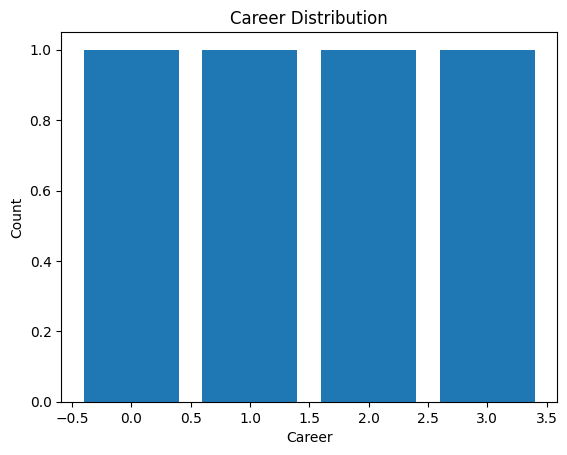

In [25]:
import matplotlib.pyplot as plt

career_counts = students["career"].value_counts()

plt.bar(career_counts.index, career_counts.values)
plt.xlabel("Career")
plt.ylabel("Count")
plt.title("Career Distribution")
plt.show()

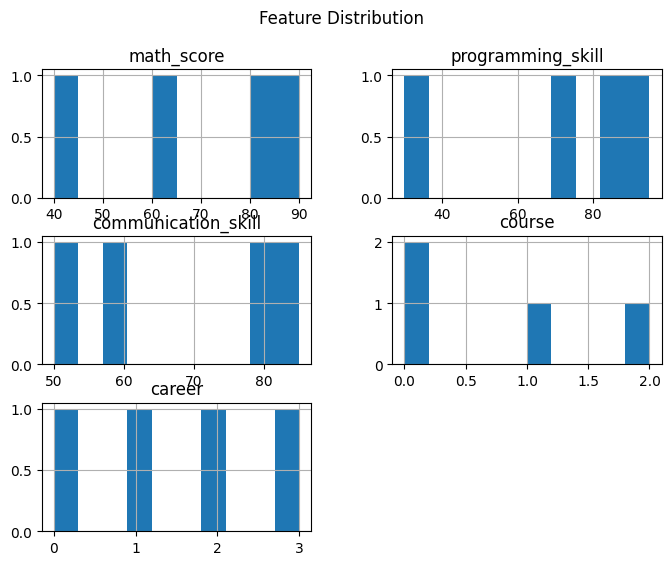

In [27]:
students.hist(figsize=(8,6))
plt.suptitle("Feature Distribution")
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted', zero_division=0))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

